# MZI Lattice: S-Parameters to Block Mode

This example is the starter tutorial for the time-domain Block mode workflow. It uses a four-stage Mach-Zehnder interferometer (MZI) lattice and follows the same signal path several ways:

1. Build the frequency-domain SAX netlist and inspect the `s_params` dictionary.
2. Run the same sweep through `SParameterSimulation` to show the simulator interface.
3. Fit the S-parameter response with a pole-residue model and extract the state-space form.
4. Run the same lattice as a causal time-domain Block mode simulation.

The main idea is simple: S-parameters describe steady-state behavior versus wavelength, while Block mode simulates the time response of the same optical network after those S-parameters have been converted into discrete-time state-space filters.

## 1. Imports

The example uses two different layers of Simphony:

- SAX models for the direct frequency-domain S-parameter dictionary.
- Simphony `Circuit` and `BlockModeSimulation` for the time-domain block simulation.

The small custom laser below is intentionally simple. It emits a constant complex envelope so the lattice response is easy to interpret.


In [1]:
import os
import warnings

os.environ.setdefault('JAX_PLATFORMS', 'cpu')
warnings.filterwarnings('ignore', message='Could not validate netlist.*')
warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive.*')

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import sax
from scipy.constants import speed_of_light

from simphony.circuit.circuit import Circuit
from simphony.component.component import BlockModeComponent
from simphony.component.port import Port
from simphony.libraries import old_ideal
from simphony.libraries.ideal.s_parameters import optical_s_parameter_placeholder
from simphony.signal.block_mode import BlockModeOpticalSignal
from simphony.simulation.block_mode import BlockModeSimulation, BlockModeSimulationParameters
from simphony.simulation.s_parameter import SParameterSimulation, SParameterSimulationParameters
from simphony.time_domain.vector_fitting.z_domain import (
    pole_residue_response_discrete,
    state_space_discrete,
    state_space_response_discrete_structured,
    vector_fitting_discrete,
)
from simphony.utils import dict_to_matrix


## 2. Choose the lattice design

Each MZI stage uses a short arm and a long arm to set the interference period. In this lattice, the delay difference doubles from stage to stage, which gives the cascade a sharper passband than a single MZI.

The variables below are in microns because the `old_ideal` SAX models use `wl` in microns and waveguide `length` in microns.


In [2]:
ORDER = 4
BASE_LENGTH_UM = 10.0
DELAY_UNIT_UM = 14.33
TUNING_OFFSETS_UM = np.array([0.24265, 0.48530, 0.30821, 0.61641])

stage_multipliers = 2 ** np.arange(ORDER)
short_arm_lengths_um = np.full(ORDER, BASE_LENGTH_UM)
long_arm_lengths_um = BASE_LENGTH_UM + stage_multipliers * DELAY_UNIT_UM + TUNING_OFFSETS_UM

for stage, (short_length, long_length) in enumerate(zip(short_arm_lengths_um, long_arm_lengths_um)):
    print(
        f'stage {stage}: short arm = {short_length:.3f} um, '
        f'long arm = {long_length:.3f} um, '
        f'delta = {long_length - short_length:.3f} um'
    )


stage 0: short arm = 10.000 um, long arm = 24.573 um, delta = 14.573 um
stage 1: short arm = 10.000 um, long arm = 39.145 um, delta = 29.145 um
stage 2: short arm = 10.000 um, long arm = 67.628 um, delta = 57.628 um
stage 3: short arm = 10.000 um, long arm = 125.256 um, delta = 115.256 um


## 3. Build the frequency-domain netlist

A SAX netlist is a dictionary with `instances`, `connections`, and `ports`. For S-parameter simulation, the connections represent physical port joins, not a time-domain execution order.

The top-level ports are:

- `o0`: input used in this example.
- `o1`: unused input.
- `o2`: drop output.
- `o3`: through output used in this example.

This explicit netlist is a good first tutorial form because every coupler and waveguide is visible. A PCell can generate this kind of netlist automatically; we discuss that after seeing the direct form.


In [3]:
def frequency_domain_lattice_netlist(order=ORDER):
    instances = {}
    connections = {}

    for stage in range(order):
        splitter = f'dc{2 * stage}'
        combiner = f'dc{2 * stage + 1}'
        short_wg = f'wg{2 * stage}'
        long_wg = f'wg{2 * stage + 1}'

        instances[splitter] = 'directional_coupler'
        instances[combiner] = 'directional_coupler'
        instances[short_wg] = 'waveguide'
        instances[long_wg] = 'waveguide'

        connections[f'{short_wg},o0'] = f'{splitter},o3'
        connections[f'{short_wg},o1'] = f'{combiner},o2'
        connections[f'{long_wg},o0'] = f'{splitter},o1'
        connections[f'{long_wg},o1'] = f'{combiner},o0'

        if stage < order - 1:
            next_splitter = f'dc{2 * (stage + 1)}'
            connections[f'{combiner},o1'] = f'{next_splitter},o2'

    ports = {
        'o0': 'dc0,o2',
        'o1': 'dc0,o0',
        'o2': f'dc{2 * order - 1},o3',
        'o3': f'dc{2 * order - 1},o1',
    }

    return {'instances': instances, 'connections': connections, 'ports': ports}


def frequency_domain_lattice_settings(wavelengths_um):
    settings = {'wl': wavelengths_um}

    for stage, (short_length, long_length) in enumerate(zip(short_arm_lengths_um, long_arm_lengths_um)):
        settings[f'wg{2 * stage}'] = {'length': short_length}
        settings[f'wg{2 * stage + 1}'] = {'length': long_length}

    return settings


frequency_netlist = frequency_domain_lattice_netlist()
sax_models = {
    'waveguide': old_ideal.waveguide,
    'directional_coupler': old_ideal.coupler,
}

print('instances:', len(frequency_netlist['instances']))
print('connections:', len(frequency_netlist['connections']))
print('ports:', frequency_netlist['ports'])


instances: 16
connections: 19
ports: {'o0': 'dc0,o2', 'o1': 'dc0,o0', 'o2': 'dc7,o3', 'o3': 'dc7,o1'}


## 4. Compute and inspect the `s_params` dictionary

Calling a SAX circuit returns a dictionary. Each key is `(output_port, input_port)` and each value is the complex transfer function sampled over the requested wavelengths.

For example, `s_params[('o3', 'o0')]` is the through-port transfer from input `o0` to output `o3`.


In [4]:
wavelengths_um = np.linspace(1.50, 1.60, 800)
wavelengths_m = wavelengths_um * 1e-6

sax_circuit, _ = sax.circuit(frequency_netlist, sax_models)
s_params = sax_circuit(**frequency_domain_lattice_settings(wavelengths_um))

TRANSFER_KEY = ('o3', 'o0')
transmission_sparam = np.abs(s_params[TRANSFER_KEY]) ** 2

print(f's_params is a {type(s_params).__name__} with {len(s_params)} entries')
print('first eight keys:')
for key in list(s_params.keys())[:8]:
    print(' ', key, 'shape =', np.asarray(s_params[key]).shape)
print(f'example {TRANSFER_KEY} first samples:', np.round(s_params[TRANSFER_KEY][:5], 4))


s_params is a dict with 16 entries
first eight keys:
  ('o0', 'o0') shape = (800,)
  ('o0', 'o1') shape = (800,)
  ('o0', 'o2') shape = (800,)
  ('o0', 'o3') shape = (800,)
  ('o1', 'o0') shape = (800,)
  ('o1', 'o1') shape = (800,)
  ('o1', 'o2') shape = (800,)
  ('o1', 'o3') shape = (800,)
example ('o3', 'o0') first samples: [-0.0193-0.1578j -0.0624-0.2034j -0.1226-0.239j  -0.1974-0.2595j
 -0.2827-0.2604j]


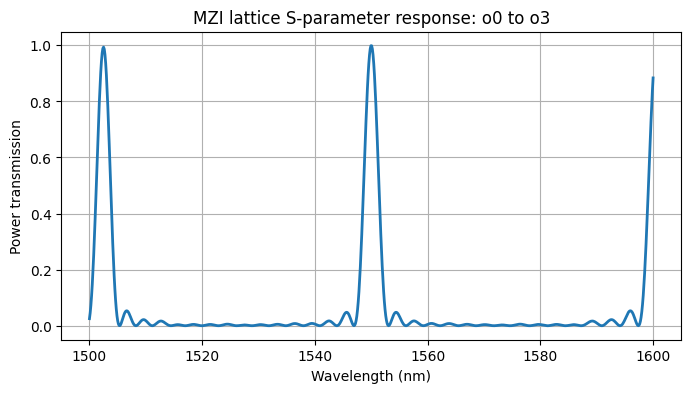

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(wavelengths_um * 1e3, transmission_sparam, linewidth=2)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power transmission')
plt.title('MZI lattice S-parameter response: o0 to o3')
plt.grid(True)
plt.show()


## 5. Run the same sweep with `SParameterSimulation`

The direct `sax.circuit(...)` call is the shortest way to evaluate this netlist. `SParameterSimulation` evaluates the same steady-state response through Simphony's `Circuit` and `Simulation` API.

In this example both paths use the same SAX model functions:

- `old_ideal.waveguide` for each arm.
- `old_ideal.coupler`, wrapped only so it accepts the `wl` keyword that the simulator passes to SAX models.

Since the models, netlist, and settings are the same, the two curves should sit directly on top of each other. The point of this section is not to show a different result; it is to show the simulation interface that later examples reuse.

In [1]:
def coupler_accepts_wavelength(*, wl=None, coupling=0.5, loss=0.0, phi=np.pi / 2):
    # `old_ideal.coupler` is wavelength independent, but SParameterSimulation
    # calls wrapped SAX models with a `wl` keyword.
    return old_ideal.coupler(coupling=coupling, loss=loss, phi=phi)


sparameter_models = {
    'waveguide': old_ideal.waveguide,
    'directional_coupler': coupler_accepts_wavelength,
}

sparameter_settings = {}
for stage, (short_length, long_length) in enumerate(zip(short_arm_lengths_um, long_arm_lengths_um)):
    sparameter_settings[f'wg{2 * stage}'] = {'length': short_length}
    sparameter_settings[f'wg{2 * stage + 1}'] = {'length': long_length}

for coupler_index in range(2 * ORDER):
    sparameter_settings[f'dc{coupler_index}'] = {}

sparameter_simulation = SParameterSimulation(
    Circuit(frequency_netlist, sparameter_models),
    sparameter_settings,
    simulation_parameters=SParameterSimulationParameters(),
)

sparameter_result = sparameter_simulation.run(wl=wavelengths_um)
transmission_simulation = np.abs(sparameter_result.s_parameters[TRANSFER_KEY]) ** 2
max_sparameter_difference = np.max(np.abs(transmission_simulation - transmission_sparam))

print('SParameterSimulation entries:', len(sparameter_result.s_parameters))
print('maximum difference from direct SAX:', float(max_sparameter_difference))

plt.figure(figsize=(8, 4))
plt.plot(wavelengths_um * 1e3, transmission_simulation, linewidth=2, label='SParameterSimulation')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power transmission')
plt.title('Direct SAX and SParameterSimulation use the same SAX models')
plt.grid(True)
plt.legend()
plt.show()

NameError: name 'np' is not defined

## 6. Fit a pole-residue model

Block mode cannot directly step a wavelength-domain S-parameter table through time. It first needs a causal discrete-time model. The pole-residue fit is that bridge.

Let the fitted transfer matrix have $q$ output ports, $m$ input ports, and $r$ poles. For this 4-port lattice, $q=m=4$ and `MODEL_ORDER` sets $r$. The discrete pole-residue model is

$$
\mathbf{H}(z) = \mathbf{D} + \sum_{k=1}^{r}\frac{\mathbf{R}_k}{z - p_k},
$$

where

$$
p_k \in \mathbb{C}, \qquad \mathbf{R}_k \in \mathbb{C}^{q \times m}, \qquad \mathbf{D} \in \mathbb{C}^{q \times m}.
$$

In the code, these are returned as `poles`, `residues`, and `feedthrough`, with

$$
\texttt{residues}[k, :, :] = \mathbf{R}_k, \qquad \texttt{feedthrough} = \mathbf{D}.
$$

The optical frequency sweep is converted to a baseband discrete-time variable using the same time step used later in Block mode:

$$
z(f) = \exp\left(-j2\pi\frac{f - f_c}{f_s}\right)
     = \exp\left(-j2\pi(f - f_c)\Delta t\right),
$$

with

$$
f_c = \frac{c}{\lambda_c}, \qquad f_s = \frac{1}{\Delta t}.
$$

Here we fit the full 4-port transfer matrix, not just the single plotted path. The next plot checks that this fitted pole-residue model reproduces the original steady-state S-parameter response.

In [7]:
DT = 1e-14
SAMPLING_FREQUENCY_HZ = 1 / DT
CENTER_WAVELENGTH_M = 1.55e-6
CENTER_FREQUENCY_HZ = speed_of_light / CENTER_WAVELENGTH_M
frequency_hz = speed_of_light / wavelengths_m
MODEL_ORDER = 40

transfer_matrix = dict_to_matrix(s_params)
port_order = sorted({port for key in s_params.keys() for port in key})
input_index = port_order.index('o0')
output_index = port_order.index('o3')

poles, residues, feedthrough, fit_mse = vector_fitting_discrete(
    MODEL_ORDER,
    transfer_matrix,
    frequency_hz,
    CENTER_FREQUENCY_HZ,
    SAMPLING_FREQUENCY_HZ,
)

fitted_response = pole_residue_response_discrete(
    frequency_hz,
    CENTER_FREQUENCY_HZ,
    SAMPLING_FREQUENCY_HZ,
    poles,
    residues,
    feedthrough,
)

transmission_fit = np.abs(fitted_response[:, output_index, input_index]) ** 2

print('port order used by matrix:', port_order)
print('transfer matrix shape:', transfer_matrix.shape)
print('poles shape:', poles.shape)
print('residues shape:', residues.shape)
print('feedthrough shape:', feedthrough.shape)
print('fit MSE:', float(fit_mse))

port order used by matrix: ['o0', 'o1', 'o2', 'o3']
transfer matrix shape: (800, 4, 4)
poles shape: (40,)
residues shape: (40, 4, 4)
feedthrough shape: (4, 4)
fit MSE: 1.873114180936402e-07


## 7. Compare the pole-residue fit with the S-parameters

This plot checks whether the fitted pole-residue model has the same steady-state frequency response as the original S-parameter dictionary. If this comparison is poor, the time-domain Block mode simulation will also be poor, because Block mode is built from this same kind of fit.

After this check, we construct the state-space matrices from the accepted pole-residue model. We do not need to reconstruct the transfer function through the ABCD matrices here; the pole-residue overlay is the relevant fit check.

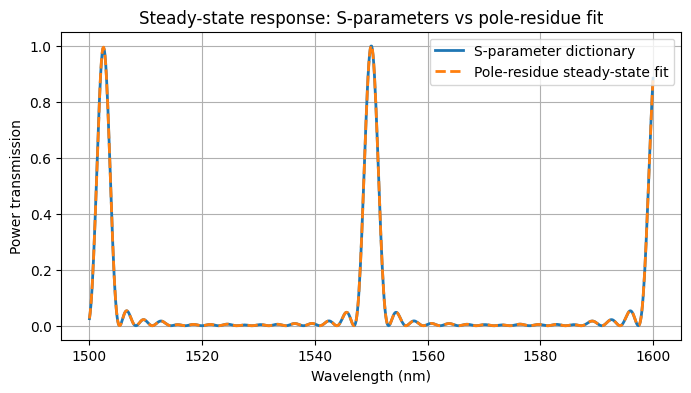

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(wavelengths_um * 1e3, transmission_sparam, label='S-parameter dictionary', linewidth=2)
plt.plot(wavelengths_um * 1e3, transmission_fit, '--', label='Pole-residue steady-state fit', linewidth=2)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power transmission')
plt.title('Steady-state response: S-parameters vs pole-residue fit')
plt.grid(True)
plt.legend()
plt.show()

### Construct the state-space model

Once the pole-residue fit is acceptable, we convert it to the state-space form that a time-domain simulator can step forward sample by sample:

$$
\mathbf{x}[n+1] = \mathbf{A}\mathbf{x}[n] + \mathbf{B}\mathbf{u}[n], \qquad
\mathbf{y}[n] = \mathbf{C}\mathbf{x}[n] + \mathbf{D}\mathbf{u}[n].
$$

For the pole-residue realization used here, the matrices are

$$
\mathbf{A} = \operatorname{kron}\left(\operatorname{diag}(p_1,\ldots,p_r), \mathbf{I}_m\right),
$$

$$
\mathbf{B} =
\begin{bmatrix}
\mathbf{I}_m \\
\mathbf{I}_m \\
\vdots \\
\mathbf{I}_m
\end{bmatrix}
\in \mathbb{C}^{rm \times m},
$$

$$
\mathbf{C}_{i,(k,j)} = (\mathbf{R}_k)_{i,j}, \qquad \mathbf{D}=\texttt{feedthrough}.
$$

This realization is not guaranteed to be minimal, but it is easy to inspect and maps directly onto the fitted pole-residue tensors.

In [9]:
A, B, C, D = state_space_discrete(poles, residues, feedthrough)

print('A shape:', A.shape)
print('B shape:', B.shape)
print('C shape:', C.shape)
print('D shape:', D.shape)

A shape: (160, 160)
B shape: (160, 4)
C shape: (4, 160)
D shape: (4, 4)


### Step the fitted state-space model

`z_domain.py` has two useful time-domain state-space response helpers:

- `state_space_response_discrete(...)` is the general dense update. It works for any valid $\mathbf{A}$, $\mathbf{B}$, $\mathbf{C}$, $\mathbf{D}$ realization.
- `state_space_response_discrete_structured(...)` assumes the realization came from `state_space_discrete(...)`. It makes certain assumptions about the shape and values of the pole-residue model and state space model for a speed up. Refer to docs for more details.

For this fitted pole-residue model, the structured method is the natural one to show. The code below drives input `o0` with a unit CW envelope and reads output `o3` for several baseband wavelengths. This is only the full-circuit state-space implementation; after this, we run the same circuit through `BlockModeSimulation` so the tutorial can explain the simulator workflow.

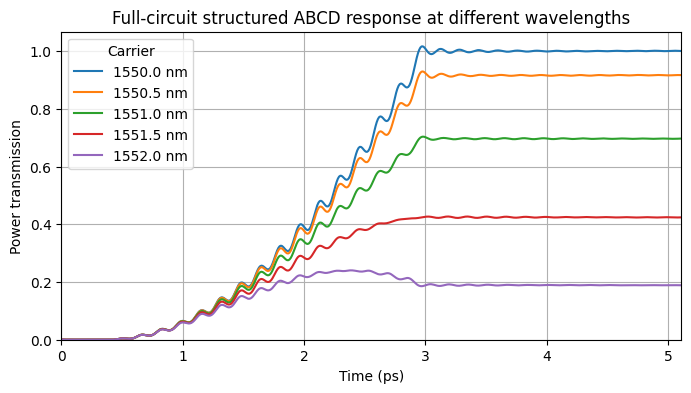

In [10]:
TIME_STEPS = 512
wavelengths_td_m = np.linspace(1.550e-6, 1.552e-6, 5)
time_ps = np.arange(TIME_STEPS) * DT * 1e12


def structured_abcd_response(wavelengths_m):
    num_ports = len(port_order)
    input_sequence = jnp.zeros((TIME_STEPS, num_ports), dtype=complex)
    input_sequence = input_sequence.at[:, input_index].set(1.0 + 0.0j)

    responses = []
    for wavelength_m in wavelengths_m:
        omega_lambda = 2 * np.pi * speed_of_light * (1 / wavelength_m - 1 / CENTER_WAVELENGTH_M) * DT
        phase = jnp.exp(1j * omega_lambda)

        y, _ = state_space_response_discrete_structured(
            phase * A,
            B,
            C,
            D,
            phase,
            input_sequence,
        )
        responses.append(np.asarray(y[:, output_index]))

    return np.stack(responses, axis=1)


structured_envelopes = structured_abcd_response(wavelengths_td_m)
structured_power_matrix = np.abs(structured_envelopes) ** 2

plt.figure(figsize=(8, 4))
for wavelength_m, power in zip(wavelengths_td_m, structured_power_matrix.T):
    plt.plot(time_ps, power, linewidth=1.5, label=f'{wavelength_m * 1e9:.1f} nm')

plt.xlabel('Time (ps)')
plt.ylabel('Power transmission')
plt.title('Full-circuit structured ABCD response at different wavelengths')
plt.xlim(time_ps[0], time_ps[-1])
plt.ylim(bottom=0)
plt.grid(True)
plt.legend(title='Carrier')
plt.show()

## 8. A short note on PCells

A PCell is a parameterized component. Instead of writing every coupler, waveguide, and connection by hand, a PCell builds a netlist, model dictionary, and settings dictionary from a smaller set of parameters.

For this starter example, the lattice is written explicitly so the mechanics are easy to see. In larger circuits, a PCell is the better abstraction because it lets you say "make an order-4 MZI lattice" and let the component generate the repeated stages internally.

During simulation, Simphony instantiates and flattens PCells before running the solver. After flattening, the Block mode simulator sees ordinary components and ordinary directed connections.


## 9. Build a directed Block mode netlist

Frequency-domain S-parameter netlists are connection-oriented. Block mode is execution-oriented: signals must flow from sources to downstream components in a directed acyclic graph.

The directed version below uses the same physical lattice, but the connection dictionary is written in signal-flow order. A small CW source drives `dc0,o2`, and the top-level output is `dc7,o1`.

For Block mode, each connection entry is interpreted as:

```python
'upstream_instance,upstream_port': 'downstream_instance,downstream_port'
```

When `port_directionality` is not supplied for an S-parameter placeholder, Simphony infers it from this directed netlist: ports on the left-hand side of `connections` are outputs, ports that appear only on the right-hand side are inputs, and unconnected S-parameter ports default to outputs. This is why the Block mode netlist is written as a signal-flow path instead of as an undirected physical join list.

The later settings cell still gives explicit direction dictionaries for the couplers and waveguides. That makes the tutorial less ambiguous and is especially helpful for reciprocal components whose physical ports can be used in more than one role.

In [11]:
class TutorialCWLaser(BlockModeComponent):
    ports = [Port(name='o0', type='optical', directionality='output')]

    def __init__(self, simulation_parameters, *, wavelength):
        self.wavelength = jnp.atleast_1d(jnp.asarray(wavelength))

    def block_mode_response(self, inputs, simulation_parameters):
        num_time_steps = simulation_parameters.num_time_steps
        num_wavelengths = self.wavelength.shape[0]
        num_modes = len(simulation_parameters.mode_identifiers)

        amplitude = jnp.zeros(
            (num_time_steps, num_wavelengths, num_modes),
            dtype=jnp.complex64,
        )
        amplitude = amplitude.at[:, :, 0].set(1.0 + 0.0j)

        return {
            'o0': BlockModeOpticalSignal(
                amplitude=amplitude,
                wavelength=self.wavelength,
            )
        }


def block_mode_lattice_netlist(order=ORDER):
    frequency_netlist = frequency_domain_lattice_netlist(order)
    instances = {'laser': 'laser', **frequency_netlist['instances']}
    connections = {'laser,o0': 'dc0,o2'}

    for stage in range(order):
        splitter = f'dc{2 * stage}'
        combiner = f'dc{2 * stage + 1}'
        short_wg = f'wg{2 * stage}'
        long_wg = f'wg{2 * stage + 1}'

        connections[f'{splitter},o3'] = f'{short_wg},o0'
        connections[f'{short_wg},o1'] = f'{combiner},o2'
        connections[f'{splitter},o1'] = f'{long_wg},o0'
        connections[f'{long_wg},o1'] = f'{combiner},o0'

        if stage < order - 1:
            next_splitter = f'dc{2 * (stage + 1)}'
            connections[f'{combiner},o1'] = f'{next_splitter},o2'

    ports = {'out': f'dc{2 * order - 1},o1'}
    return {'instances': instances, 'connections': connections, 'ports': ports}


block_netlist = block_mode_lattice_netlist()
print('directed instances:', len(block_netlist['instances']))
print('directed connections:', len(block_netlist['connections']))
print('top-level ports:', block_netlist['ports'])


directed instances: 17
directed connections: 20
top-level ports: {'out': 'dc7,o1'}


## 10. Configure Block mode models and settings

SAX components must be wrapped before Block mode can use them. `optical_s_parameter_placeholder` gives Simphony a Block mode component shell around the SAX model, and the settings provide the SAX kwargs, port roles, and vector-fitting controls for each instance.

The most important Block mode parameters are:

- `dt`: time step of the sampled envelope simulation. It sets the sampling frequency used by the discrete-time fit.
- `num_time_steps`: number of samples in the block. Components process arrays of this full length.
- `optical_baseband_wavelengths`: carrier wavelengths tracked in the envelope simulation.
- `mode_identifiers`: optical modes to simulate. This starter example uses only `te`.
- `vector_fitting_parameters`: per-SAX-component fitting controls. `model_order` and `num_frequency_samples` are the easiest accuracy/speed knobs.

Settings caveat: once an S-parameter instance setting includes simulator-only keys such as `port_directionality` or `vector_fitting_parameters`, include `sax_settings` too. If the SAX model has no arguments, write `sax_settings: {}`. Otherwise those simulator-only keys can be interpreted as SAX model parameters instead of Block mode metadata.

In [12]:
COUPLER_DIRECTIONALITY = {
    'o2': 'input',
    'o0': 'input',
    'o3': 'output',
    'o1': 'output',
}
WAVEGUIDE_DIRECTIONALITY = {
    'o0': 'input',
    'o1': 'output',
}

block_models = {
    'laser': TutorialCWLaser,
    'directional_coupler': optical_s_parameter_placeholder(
        old_ideal.coupler,
        COUPLER_DIRECTIONALITY,
        default_modes=('te',),
    ),
    'waveguide': optical_s_parameter_placeholder(
        old_ideal.waveguide,
        WAVEGUIDE_DIRECTIONALITY,
        default_modes=('te',),
    ),
}

component_vector_fit = {
    'model_order': 20,
    'min_model_order': 4,
    'max_model_order': 20,
    'num_frequency_samples': 300,
    'center_wavelength': CENTER_WAVELENGTH_M,
    'spectral_range': (1.5e-6, 1.6e-6),
}


def block_mode_lattice_settings(wavelengths_m):
    wavelengths_m = jnp.atleast_1d(jnp.asarray(wavelengths_m))
    settings = {
        'laser': {'wavelength': wavelengths_m},
    }

    for coupler_index in range(2 * ORDER):
        settings[f'dc{coupler_index}'] = {
            'sax_settings': {},
            'port_directionality': COUPLER_DIRECTIONALITY,
            'vector_fitting_parameters': component_vector_fit.copy(),
        }

    for stage, (short_length, long_length) in enumerate(zip(short_arm_lengths_um, long_arm_lengths_um)):
        settings[f'wg{2 * stage}'] = {
            'sax_settings': {'length': short_length},
            'port_directionality': WAVEGUIDE_DIRECTIONALITY,
            'vector_fitting_parameters': component_vector_fit.copy(),
        }
        settings[f'wg{2 * stage + 1}'] = {
            'sax_settings': {'length': long_length},
            'port_directionality': WAVEGUIDE_DIRECTIONALITY,
            'vector_fitting_parameters': component_vector_fit.copy(),
        }

    return settings

## 11. Run Block mode at several wavelengths

Now we run the lattice through the Block mode simulator. A `BlockModeOpticalSignal` has shape `(time, wavelength, mode)`, so one Block mode run can carry multiple baseband wavelengths at once.

The important simulator pieces are:

- `BlockModeSimulationParameters`, which define `dt`, `num_time_steps`, modes, and the baseband wavelength grid.
- `Circuit(block_netlist, block_models)`, which binds the directed netlist to the Block mode-capable component models.
- `BlockModeSimulation(...).run()`, which instantiates the circuit, fits the S-parameter components internally, and steps the directed graph.

The result below is the simulator output. It is no longer a hand-run full-circuit ABCD model; it is the actual Block mode workflow.

In [13]:
simulation_parameters = BlockModeSimulationParameters(
    mode_identifiers=('te',),
    dt=DT,
    num_time_steps=TIME_STEPS,
    optical_baseband_wavelengths=jnp.asarray(wavelengths_td_m),
    use_speed_up=True,
)

circuit = Circuit(block_netlist, block_models)
simulation = BlockModeSimulation(
    circuit,
    settings=block_mode_lattice_settings(wavelengths_td_m),
    simulation_parameters=simulation_parameters,
)
result = simulation.run()
output_signal = result.output_signals['out']

output_baseband_grid = np.asarray(output_signal.wavelength)
output_envelopes = np.asarray(output_signal.amplitude[:, :, 0])
power_matrix = np.abs(output_envelopes) ** 2
block_steady_power = power_matrix[-1, :]

print('Block mode runs:', 1)
print('tracked wavelengths:', output_baseband_grid.shape[0])
print('output amplitude shape:', output_signal.amplitude.shape)
print('output wavelength grid (nm):', np.round(output_baseband_grid * 1e9, 3))

Block mode runs: 1
tracked wavelengths: 5
output amplitude shape: (512, 5, 1)
output wavelength grid (nm): [1550.  1550.5 1551.  1551.5 1552. ]


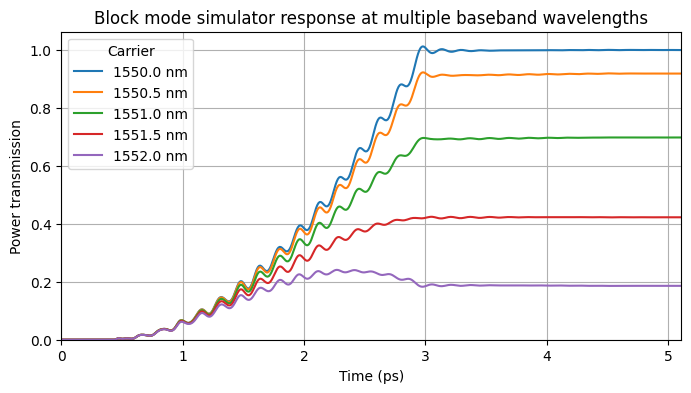

In [14]:
plt.figure(figsize=(8, 4))
for wavelength_m, power in zip(output_baseband_grid, power_matrix.T):
    plt.plot(time_ps, power, linewidth=1.5, label=f'{wavelength_m * 1e9:.1f} nm')

plt.xlabel('Time (ps)')
plt.ylabel('Power transmission')
plt.title('Block mode simulator response at multiple baseband wavelengths')
plt.xlim(time_ps[0], time_ps[-1])
plt.ylim(bottom=0)
plt.grid(True)
plt.legend(title='Carrier')
plt.show()

## 12. Wavelength mapping to the baseband grid

Each `BlockModeOpticalSignal` carries both an amplitude array and a wavelength grid. In the run above, the laser emits exactly the same wavelengths listed in `simulation_parameters.optical_baseband_wavelengths`, so the mapping is one-to-one.

More generally, after a Block mode component returns optical outputs, Simphony maps every output wavelength onto the baseband grid. It chooses the nearest baseband wavelength and applies a phase correction based on the frequency difference:

$$
\phi(t) = \exp\left[-j2\pi\left(\frac{c}{\lambda_{out}} - \frac{c}{\lambda_{baseband}}\right)t\right].
$$

If multiple output wavelengths land on the same baseband channel, their phase-corrected amplitudes are added. This keeps the arrays aligned between components while preserving the beat phase of wavelengths that do not exactly equal the baseband grid.

You can inspect the mapped wavelengths through `result.output_signals['out'].wavelength` and the corresponding envelopes through `result.output_signals['out'].amplitude`.

In [15]:
example_index = len(output_baseband_grid) // 2
example_wavelength_m = output_baseband_grid[example_index]
example_envelope = output_envelopes[:, example_index]

print('example carrier (nm):', float(example_wavelength_m * 1e9))
print('mapped output baseband grid (nm):', np.round(output_baseband_grid * 1e9, 6))
print('all output envelopes shape:', output_envelopes.shape)
print('first three complex envelope samples for example carrier:', np.round(example_envelope[:3], 5))

example carrier (nm): 1551.0
mapped output baseband grid (nm): [1550.  1550.5 1551.  1551.5 1552. ]
all output envelopes shape: (512, 5)
first three complex envelope samples for example carrier: [-0.-0.j  0.+0.j -0.-0.j]


## 13. Compare Block mode steady state with S-parameters

The final sample of each wavelength trace is an estimate of the settled response. Here it is plotted against the original S-parameter transmission at the same carrier wavelengths.

Small differences come from the finite fitting order, finite simulation time, and the fact that Block mode is running a causal discrete-time approximation of the frequency-domain model.

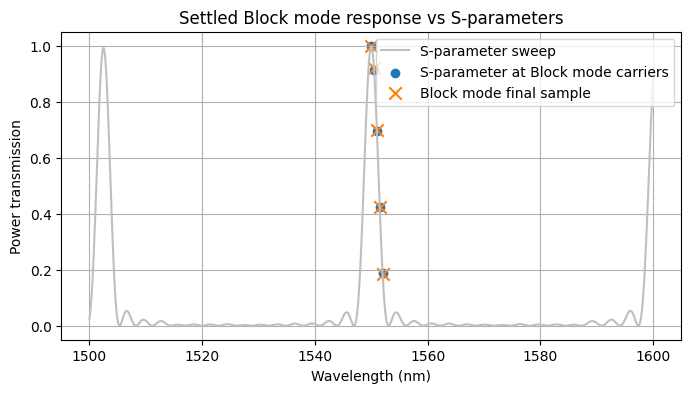

In [16]:
wavelengths_td_um = output_baseband_grid * 1e6
s_params_td = sax_circuit(**frequency_domain_lattice_settings(wavelengths_td_um))
sparam_td_power = np.abs(s_params_td[TRANSFER_KEY]) ** 2

plt.figure(figsize=(8, 4))
plt.plot(wavelengths_um * 1e3, transmission_sparam, color='0.75', label='S-parameter sweep')
plt.scatter(wavelengths_td_um * 1e3, sparam_td_power, label='S-parameter at Block mode carriers')
plt.scatter(wavelengths_td_um * 1e3, block_steady_power, marker='x', s=80, label='Block mode final sample')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power transmission')
plt.title('Settled Block mode response vs S-parameters')
plt.grid(True)
plt.legend()
plt.show()